In [ ]:
"""
==================================================
ML LEARNING JOURNEY - DAY 71
==================================================

Week: 11 of 24
Day: 71 of 168
Date: Monday, January 20, 2026
Topic: Policy Gradients & REINFORCE Algorithm


Week 11 Progress:
🔄 Day 71: Policy Gradients & REINFORCE (TODAY!)
⬜ Day 72: REINFORCE Training & Optimization
⬜ Day 73: Actor-Critic (A2C/A3C)
⬜ Day 74: A2C Training & Analysis
⬜ Day 75: PPO (Proximal Policy Optimization)
⬜ Day 76: PPO Training & Optimization
⬜ Day 77: Algorithm Comparison & Week Completion

Progress: 14.3% (1/7 days)

==================================================
🎯 Week 11: Policy Gradient Methods & Advanced RL

NEW PARADIGM: Moving from Value-Based to Policy-Based RL!

Week 10 Recap:
✅ Value-based methods (DQN family)
   - Learn Q(s,a) → derive policy
   - Discrete actions
   - Off-policy learning

Week 11 Focus:
🆕 Policy-based methods
   - Learn π(a|s) directly
   - Works with continuous actions
   - On-policy learning
   - Different optimization approach

==================================================
🎯 Today's Learning Objectives:

1. Policy Gradient Fundamentals
   - What is a policy?
   - Parameterized policies (neural networks)
   - Why learn policies directly?
   - Advantages over value-based methods

2. Policy Gradient Theorem
   - Objective function (expected return)
   - Gradient of expected return
   - REINFORCE derivation
   - Mathematical foundations

3. REINFORCE Algorithm
   - Monte Carlo policy gradient
   - Episode-based updates
   - Gradient estimation
   - Baseline methods (variance reduction)

4. Implementation
   - Policy network architecture
   - Trajectory collection
   - Gradient computation
   - Training loop

5. Comparison with DQN
   - When to use policy gradients?
   - Advantages and disadvantages
   - Continuous vs discrete actions
   - Sample efficiency

📚 Today's Structure:
Part 1 (2h): Policy Gradient Theory
Part 2 (2h): REINFORCE Algorithm Deep Dive
Part 3 (2h): Implementation (CartPole)
Part 4 (2h): Analysis & Comparison with DQN

Total Time: ~8 hours

🎯 SUCCESS CRITERIA:
✅ Understand policy gradient theorem
✅ Derive REINFORCE algorithm
✅ Implement policy network
✅ Train on CartPole environment
✅ Achieve >150 average reward
✅ Compare with DQN performance
✅ Understand variance issues

💡 Key Insight:
Policy gradients are fundamentally different from DQN!
- DQN: Learn values → act greedily
- Policy Gradients: Learn actions directly

This opens doors to:
- Continuous action spaces (robotics!)
- Stochastic policies
- Natural exploration
- Different optimization landscape

Let's dive into policy-based RL! 🚀

==================================================
"""

In [6]:
# ==================================================
# IMPORT LIBRARIES
# ==================================================

print("=" * 80)
print("📚 IMPORTING LIBRARIES")
print("=" * 80)

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
import random
import time
import os
from datetime import datetime

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical

# Gymnasium (OpenAI Gym)
import gymnasium as gym

print("✅ Libraries imported!")

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Using device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

# Matplotlib settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Create results directories
os.makedirs('results/reinforce', exist_ok=True)
os.makedirs('results/comparisons', exist_ok=True)
os.makedirs('results/models', exist_ok=True)

print("\n✅ Setup complete!")
print("=" * 80)
print(f"\n📊 PyTorch version: {torch.__version__}")
print(f"📊 NumPy version: {np.__version__}")
print(f"📊 Gymnasium version: {gym.__version__}")
print(f"📊 Random seed: 42")
print("=" * 80)

print("\n🎯 Ready for Day 71 - Policy Gradients!")
print("=" * 80)

📚 IMPORTING LIBRARIES
✅ Libraries imported!

🖥️  Using device: cpu

✅ Setup complete!

📊 PyTorch version: 2.9.1+cpu
📊 NumPy version: 2.3.5
📊 Gymnasium version: 1.2.2
📊 Random seed: 42

🎯 Ready for Day 71 - Policy Gradients!


In [7]:
print("\n" + "=" * 80)
print("📖 PART 1: POLICY GRADIENT FUNDAMENTALS")
print("=" * 80)


📖 PART 1: POLICY GRADIENT FUNDAMENTALS


In [8]:
# ==================================================
# EXERCISE 1.1: POLICY GRADIENT THEORY
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.1: Understanding Policy Gradients")
print("=" * 80)

"""
📖 THEORY: From Value-Based to Policy-Based RL

PARADIGM SHIFT:

Value-Based (DQN - What we did in Week 10):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Learn Q(s,a) - value of taking action a in state s
2. Policy is implicit: π(s) = argmax_a Q(s,a)
3. Act greedily based on learned values
4. Works great for discrete actions

Example: CartPole
- Learn Q(left) and Q(right) for each state
- Choose action with higher Q-value
- Policy = greedy selection

Policy-Based (REINFORCE - What we're learning today):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Learn π(a|s; θ) - probability of action a given state s
2. Policy is explicit: parameterized by neural network weights θ
3. Sample actions from learned distribution
4. Works with continuous AND discrete actions

Example: CartPole
- Learn P(left) and P(right) for each state
- Sample action from probability distribution
- Policy = stochastic sampling

KEY DIFFERENCES:

┌─────────────────────┬──────────────────────┬──────────────────────┐
│     Aspect          │   Value-Based (DQN)  │  Policy-Based (PG)   │
├─────────────────────┼──────────────────────┼──────────────────────┤
│ What we learn       │ Q(s,a) values        │ π(a|s) policy        │
│ Policy type         │ Deterministic        │ Stochastic           │
│ Action space        │ Discrete only        │ Discrete + Continuous│
│ Action selection    │ argmax Q(s,a)        │ Sample from π(a|s)   │
│ Exploration         │ ε-greedy (external)  │ Built-in (stochastic)│
│ Gradient target     │ Q-values             │ Policy parameters    │
│ Update frequency    │ Every step (off-pol) │ After episode (on-p) │
│ Sample efficiency   │ High (replay buffer) │ Low (fresh samples)  │
│ Convergence         │ Can be unstable      │ More stable          │
│ Local optima        │ Rare                 │ Common               │
└─────────────────────┴──────────────────────┴──────────────────────┘

WHY POLICY GRADIENTS?

Advantages:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Continuous Actions
   - DQN: Can't handle infinite action spaces
   - PG: Natural for continuous control (robot joints, steering angle)
   
   Example: Self-driving car
   - Steering angle: -30° to +30° (infinite choices!)
   - DQN: Would need to discretize (lose precision)
   - PG: Output mean and std of Gaussian distribution

2. Stochastic Policies
   - Some problems need randomness
   - Rock-Paper-Scissors: deterministic policy loses!
   - PG naturally learns optimal stochastic policy

3. Simpler in Some Cases
   - High-dimensional action spaces
   - Policy might be simpler than value function
   
   Example: Robot with 7 joints
   - Q-function: Q(state, 7D action) - complex!
   - Policy: π(7D action | state) - can be simpler

4. Better Convergence Guarantees
   - Policy gradient: guaranteed to converge to local optimum
   - Q-learning: can diverge (especially with function approximation)

Disadvantages:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Sample Inefficient
   - Need fresh experiences (on-policy)
   - Can't reuse old data like DQN
   - Slower learning

2. High Variance
   - Monte Carlo estimates are noisy
   - Needs many episodes to average out
   - Variance reduction techniques essential

3. Local Optima
   - Can get stuck in suboptimal policies
   - Gradient descent on policy space has many local minima

4. Sensitive to Hyperparameters
   - Learning rate especially critical
   - Too high: policy collapses
   - Too low: very slow learning

WHEN TO USE EACH?

Use DQN (Value-Based):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Discrete action spaces
✓ Sample efficiency matters
✓ Deterministic optimal policy
✓ Can afford experience replay

Examples: Atari games, board games, discrete control

Use Policy Gradients:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Continuous actions
✓ Stochastic policies needed
✓ High-dimensional action spaces
✓ Simpler policy than value function

Examples: Robotics, continuous control, strategic games

MATHEMATICAL SETUP:

Policy Parameterization:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
π(a|s; θ) - Policy parameterized by neural network weights θ

For discrete actions (like CartPole):
- Network outputs logits for each action
- Apply softmax to get probabilities
- π(a|s; θ) = softmax(neural_net(s; θ))

For continuous actions (like robot control):
- Network outputs mean μ and std σ
- Actions sampled from Gaussian: a ~ N(μ(s;θ), σ(s;θ))

Objective Function:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Goal: Maximize expected return

J(θ) = E_π[R(τ)]

Where:
- τ = (s₀, a₀, r₀, s₁, a₁, r₁, ...) is a trajectory
- R(τ) = Σ γᵗ rₜ is the discounted return
- E_π means expectation over trajectories from policy π

In plain English:
"We want to find policy parameters θ that maximize the expected 
total reward we get when following that policy"

The Challenge:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
How do we optimize J(θ)?
- Can't compute expectation exactly (infinite trajectories!)
- Can't differentiate through environment dynamics
- Need to estimate gradient from sample trajectories

This is where REINFORCE comes in! (Next section)

INTUITION:

Think of it like training a student:

Value-Based (DQN):
- Teach student the value of different choices
- Student picks best choice based on learned values
- Like teaching by explaining consequences

Policy-Based (PG):
- Teach student what to do directly
- Student learns actions themselves
- Like teaching by demonstration and feedback

Both work, but for different situations!

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

print("\n💡 Key Concepts Summary:")
print("=" * 80)

summary = """
POLICY GRADIENT FUNDAMENTALS:

1. PARADIGM SHIFT
   Value-Based → Policy-Based
   Learn Q(s,a) → Learn π(a|s) directly

2. KEY ADVANTAGES
   ✓ Handles continuous actions
   ✓ Natural stochastic policies
   ✓ Better convergence guarantees
   ✓ Simpler in high dimensions

3. KEY DISADVANTAGES
   ✗ Sample inefficient (on-policy)
   ✗ High variance (Monte Carlo)
   ✗ Prone to local optima
   ✗ Hyperparameter sensitive

4. WHEN TO USE
   - Continuous action spaces
   - Stochastic policies needed
   - Robotics and control tasks

5. MATHEMATICAL GOAL
   Maximize: J(θ) = E_π[R(τ)]
   Find: θ* = argmax_θ J(θ)
   
Next: Policy Gradient Theorem & REINFORCE! 🚀
"""

print(summary)

print("\n✅ Exercise 1.1 Complete!")
print("=" * 80)


EXERCISE 1.1: Understanding Policy Gradients

💡 Key Concepts Summary:

POLICY GRADIENT FUNDAMENTALS:

1. PARADIGM SHIFT
   Value-Based → Policy-Based
   Learn Q(s,a) → Learn π(a|s) directly

2. KEY ADVANTAGES
   ✓ Handles continuous actions
   ✓ Natural stochastic policies
   ✓ Better convergence guarantees
   ✓ Simpler in high dimensions

3. KEY DISADVANTAGES
   ✗ Sample inefficient (on-policy)
   ✗ High variance (Monte Carlo)
   ✗ Prone to local optima
   ✗ Hyperparameter sensitive

4. WHEN TO USE
   - Continuous action spaces
   - Stochastic policies needed
   - Robotics and control tasks

5. MATHEMATICAL GOAL
   Maximize: J(θ) = E_π[R(τ)]
   Find: θ* = argmax_θ J(θ)

Next: Policy Gradient Theorem & REINFORCE! 🚀


✅ Exercise 1.1 Complete!



EXERCISE 1.2: Policy Gradient Theorem

💡 Policy Gradient Theorem Summary:

POLICY GRADIENT THEOREM:

GOAL:
  Maximize J(θ) = E_π[R(τ)]

GRADIENT:
  ∇_θ J(θ) = E_π[(Σₜ ∇_θ log π_θ(aₜ|sₜ)) R(τ)]

MONTE CARLO ESTIMATE:
  ∇_θ J(θ) ≈ (1/N) Σᵢ (Σₜ ∇_θ log π_θ(aₜ⁽ⁱ⁾|sₜ⁽ⁱ⁾)) R(τ⁽ⁱ⁾)

INTUITION:
  "Increase probability of actions that led to good outcomes"

KEY PROPERTIES:
  ✓ Model-free (don't need environment dynamics)
  ✓ Works with any differentiable policy
  ✓ Handles continuous and discrete actions
  ✗ High variance (Monte Carlo estimation)
  ✗ Sample inefficient (on-policy)

NEXT: REINFORCE Algorithm (practical implementation)



C:\Users\audrey\AppData\Local\Temp\ipykernel_24848\521928824.py:304: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\audrey\AppData\Local\Temp\ipykernel_24848\521928824.py:305: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig('results/reinforce/policy_gradient_concept.png', dpi=300, bbox_inches='tight')



✅ Visualization saved!


C:\Users\audrey\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


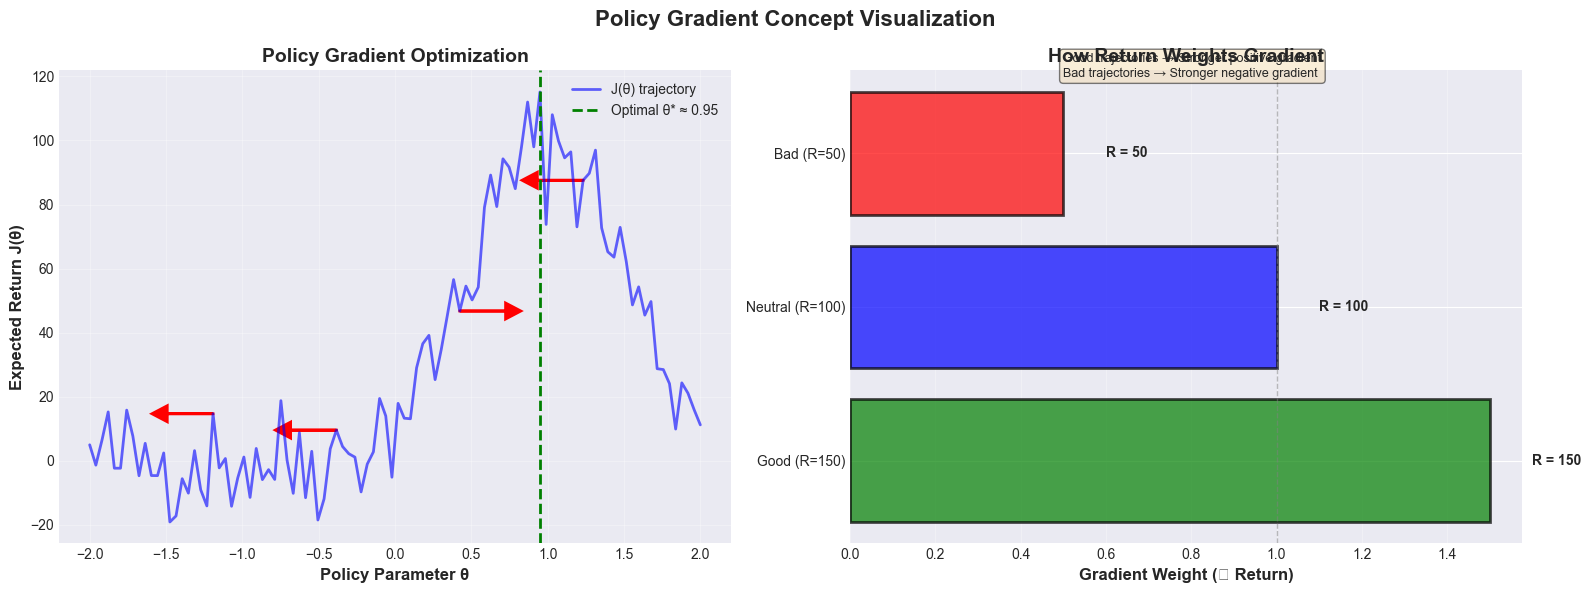


✅ Exercise 1.2 Complete!


In [9]:
# ==================================================
# EXERCISE 1.2: POLICY GRADIENT THEOREM
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.2: Policy Gradient Theorem")
print("=" * 80)

"""
📖 THEORY: The Policy Gradient Theorem

THE CENTRAL QUESTION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

We want to maximize: J(θ) = E_π[R(τ)]

How do we compute ∇_θ J(θ)? (gradient w.r.t. policy parameters)

This seems impossible because:
1. Expectation is over all possible trajectories (infinite!)
2. Environment dynamics are unknown/non-differentiable
3. Rewards depend on stochastic policy and environment

The Policy Gradient Theorem solves this! 🎉

DERIVATION (Step by Step):

Step 1: Write out the objective
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

J(θ) = E_π[R(τ)]
     = ∫ P(τ|θ) R(τ) dτ

Where:
- τ = (s₀, a₀, r₀, s₁, a₁, r₁, ..., s_T, a_T, r_T) is a trajectory
- P(τ|θ) is probability of trajectory under policy π_θ
- R(τ) = Σₜ γᵗ rₜ is the return

Step 2: Expand trajectory probability
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

P(τ|θ) = p(s₀) ∏ₜ π_θ(aₜ|sₜ) p(sₜ₊₁|sₜ, aₜ)

Where:
- p(s₀) = initial state distribution
- π_θ(aₜ|sₜ) = policy (depends on θ!) ✓
- p(sₜ₊₁|sₜ, aₜ) = environment dynamics (unknown!)

Step 3: Take gradient
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

∇_θ J(θ) = ∇_θ ∫ P(τ|θ) R(τ) dτ
         = ∫ ∇_θ P(τ|θ) R(τ) dτ

Problem: ∇_θ P(τ|θ) involves environment dynamics!

Step 4: Log-derivative trick
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Use the identity: ∇_θ P(τ|θ) = P(τ|θ) ∇_θ log P(τ|θ)

(Proof: ∇ log f = (∇f)/f, so ∇f = f ∇ log f)

Then:
∇_θ J(θ) = ∫ P(τ|θ) ∇_θ log P(τ|θ) R(τ) dτ
         = E_π[∇_θ log P(τ|θ) R(τ)]

Step 5: Simplify log P(τ|θ)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

log P(τ|θ) = log p(s₀) + Σₜ log π_θ(aₜ|sₜ) + Σₜ log p(sₜ₊₁|sₜ, aₜ)

Take gradient:
∇_θ log P(τ|θ) = ∇_θ Σₜ log π_θ(aₜ|sₜ)  [other terms don't depend on θ!]
               = Σₜ ∇_θ log π_θ(aₜ|sₜ)

Step 6: Final form
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

∇_θ J(θ) = E_π[(Σₜ ∇_θ log π_θ(aₜ|sₜ)) (Σₜ γᵗ rₜ)]

This is the POLICY GRADIENT THEOREM! 🎉

WHAT DOES THIS MEAN?

Intuitive Interpretation:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

For each trajectory τ:
1. Compute return R(τ) = Σₜ γᵗ rₜ
2. Compute log-probabilities: log π_θ(aₜ|sₜ) for each action
3. Take gradients: ∇_θ log π_θ(aₜ|sₜ)
4. Weight by return: gradient × R(τ)

In plain English:
"If trajectory had good return → increase probability of actions taken
 If trajectory had bad return → decrease probability of actions taken"

No need to know environment dynamics! 🎉

KEY INSIGHT - Why this works:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

The environment dynamics p(s'|s,a) don't depend on θ, so they 
disappear when we take ∇_θ!

We only need:
✓ Policy π_θ(a|s) - we control this!
✓ Rewards rₜ - we observe these!

We DON'T need:
✗ Environment dynamics p(s'|s,a)
✗ Value functions Q(s,a) or V(s)

PRACTICAL FORM (Monte Carlo Estimate):

Since we can't compute expectation exactly, we sample N trajectories:

∇_θ J(θ) ≈ (1/N) Σᵢ (Σₜ ∇_θ log π_θ(aₜ⁽ⁱ⁾|sₜ⁽ⁱ⁾)) R(τ⁽ⁱ⁾)

Algorithm:
1. Collect N trajectories using current policy π_θ
2. For each trajectory, compute return R(τ)
3. Compute gradient estimate (above formula)
4. Update: θ ← θ + α ∇_θ J(θ)
5. Repeat!

This is the REINFORCE algorithm! (Next section)

VARIANCE PROBLEM:

Issue: Monte Carlo estimates have HIGH VARIANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Same policy can produce very different returns due to randomness:
- Sometimes lucky → high R(τ)
- Sometimes unlucky → low R(τ)

This makes gradient estimates noisy!

Example: CartPole
- Good policy might get 200 reward (lucky)
- Same policy might get 50 reward (unlucky pole angle)
- Gradient estimate varies wildly!

Solutions (we'll cover later):
1. Use baseline (subtract average return)
2. Use advantage function (actor-critic)
3. Use more samples (but expensive!)

CAUSALITY INSIGHT:

Improved form - actions only affect future rewards:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

∇_θ J(θ) = E_π[Σₜ ∇_θ log π_θ(aₜ|sₜ) (Σₖ₌ₜ γᵏ⁻ᵗ rₖ)]
                                        └─────────┘
                                        "reward-to-go"
                                        from time t onward

Why better:
- Action at time t can't affect past rewards (causality!)
- Only credit future rewards to current action
- Reduces variance slightly

COMPARISON: Policy Gradient vs Q-Learning

┌────────────────────┬───────────────────┬──────────────────┐
│     Property       │  Policy Gradient  │   Q-Learning     │
├────────────────────┼───────────────────┼──────────────────┤
│ What we optimize   │ J(θ) directly     │ Bellman error    │
│ Gradient target    │ Returns R(τ)      │ TD error         │
│ Update rule        │ ∇_θ log π × R     │ ∇_θ (Q - target)²│
│ Data needed        │ Full trajectories │ Single steps     │
│ Sample efficiency  │ Low (on-policy)   │ High (off-policy)│
│ Variance           │ High (MC)         │ Lower (bootstrap)│
│ Bias               │ None (MC)         │ Some (bootstrap) │
│ Action spaces      │ Any               │ Discrete only    │
└────────────────────┴───────────────────┴──────────────────┘

MATHEMATICAL BEAUTY:

The policy gradient theorem is beautiful because:
1. Environment dynamics cancel out! (don't need model)
2. Computable from samples! (Monte Carlo)
3. Applies to any differentiable policy! (neural nets)
4. Works for any reward structure! (sparse, dense, etc.)

This is why policy gradients are so powerful! 🎉

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

print("\n💡 Policy Gradient Theorem Summary:")
print("=" * 80)

theorem_summary = """
POLICY GRADIENT THEOREM:

GOAL:
  Maximize J(θ) = E_π[R(τ)]

GRADIENT:
  ∇_θ J(θ) = E_π[(Σₜ ∇_θ log π_θ(aₜ|sₜ)) R(τ)]

MONTE CARLO ESTIMATE:
  ∇_θ J(θ) ≈ (1/N) Σᵢ (Σₜ ∇_θ log π_θ(aₜ⁽ⁱ⁾|sₜ⁽ⁱ⁾)) R(τ⁽ⁱ⁾)

INTUITION:
  "Increase probability of actions that led to good outcomes"

KEY PROPERTIES:
  ✓ Model-free (don't need environment dynamics)
  ✓ Works with any differentiable policy
  ✓ Handles continuous and discrete actions
  ✗ High variance (Monte Carlo estimation)
  ✗ Sample inefficient (on-policy)

NEXT: REINFORCE Algorithm (practical implementation)
"""

print(theorem_summary)

# Visualize the concept
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Policy Gradient Concept Visualization', fontsize=16, fontweight='bold')

# 1. Gradient direction visualization
ax1 = axes[0]
theta_range = np.linspace(-2, 2, 100)

# Simulate different returns for different policy parameters
returns = []
for theta in theta_range:
    # Simulate: better policies (theta closer to 1) get higher returns
    base_return = 100 * np.exp(-2 * (theta - 1)**2)
    noisy_return = base_return + np.random.normal(0, 10)
    returns.append(noisy_return)

ax1.plot(theta_range, returns, linewidth=2, color='blue', alpha=0.6, label='J(θ) trajectory')

# Show gradient direction
optimal_idx = np.argmax(returns)
optimal_theta = theta_range[optimal_idx]
ax1.axvline(optimal_theta, color='green', linestyle='--', linewidth=2, label=f'Optimal θ* ≈ {optimal_theta:.2f}')

# Show gradient arrows
sample_points = [20, 40, 60, 80]
for idx in sample_points:
    theta = theta_range[idx]
    j_val = returns[idx]
    
    # Compute approximate gradient
    if idx < len(returns) - 5:
        grad = (returns[idx + 5] - returns[idx]) / (theta_range[idx + 5] - theta_range[idx])
        arrow_len = 0.3 * np.sign(grad)
        ax1.arrow(theta, j_val, arrow_len, 0, head_width=5, head_length=0.1, 
                 fc='red', ec='red', linewidth=2)

ax1.set_xlabel('Policy Parameter θ', fontsize=12, fontweight='bold')
ax1.set_ylabel('Expected Return J(θ)', fontsize=12, fontweight='bold')
ax1.set_title('Policy Gradient Optimization', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Log probability weighting
ax2 = axes[1]

# Simulate trajectory returns
good_trajectory = 150
bad_trajectory = 50
neutral_trajectory = 100

trajectories = [
    ('Good (R=150)', good_trajectory, 'green'),
    ('Neutral (R=100)', neutral_trajectory, 'blue'),
    ('Bad (R=50)', bad_trajectory, 'red')
]

# Show how gradient is weighted by return
actions_per_traj = 5
x_pos = np.arange(len(trajectories))

for i, (label, return_val, color) in enumerate(trajectories):
    # Each trajectory has multiple actions
    grad_magnitude = return_val / 100  # Normalize for visualization
    
    ax2.barh(i, grad_magnitude, color=color, alpha=0.7, edgecolor='black', linewidth=2)
    ax2.text(grad_magnitude + 0.1, i, f'R = {return_val}', 
            va='center', fontweight='bold', fontsize=10)

ax2.set_yticks(x_pos)
ax2.set_yticklabels([t[0] for t in trajectories])
ax2.set_xlabel('Gradient Weight (∝ Return)', fontsize=12, fontweight='bold')
ax2.set_title('How Return Weights Gradient', fontsize=14, fontweight='bold')
ax2.axvline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.grid(True, alpha=0.3, axis='x')

# Add annotation
ax2.text(0.5, 2.5, 'Good trajectories → Stronger positive gradient\nBad trajectories → Stronger negative gradient',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=9, ha='left')

plt.tight_layout()
plt.savefig('results/reinforce/policy_gradient_concept.png', dpi=300, bbox_inches='tight')
print("\n✅ Visualization saved!")
plt.show()

print("\n✅ Exercise 1.2 Complete!")
print("=" * 80)


In [10]:
print("\n" + "=" * 80)
print("📐 PART 2: POLICY GRADIENT THEOREM & REINFORCE ALGORITHM")
print("=" * 80)



📐 PART 2: POLICY GRADIENT THEOREM & REINFORCE ALGORITHM



EXERCISE 2.1: Policy Gradient Theorem Derivation

📐 Policy Gradient Theorem Visualization:
✅ Visualization saved!


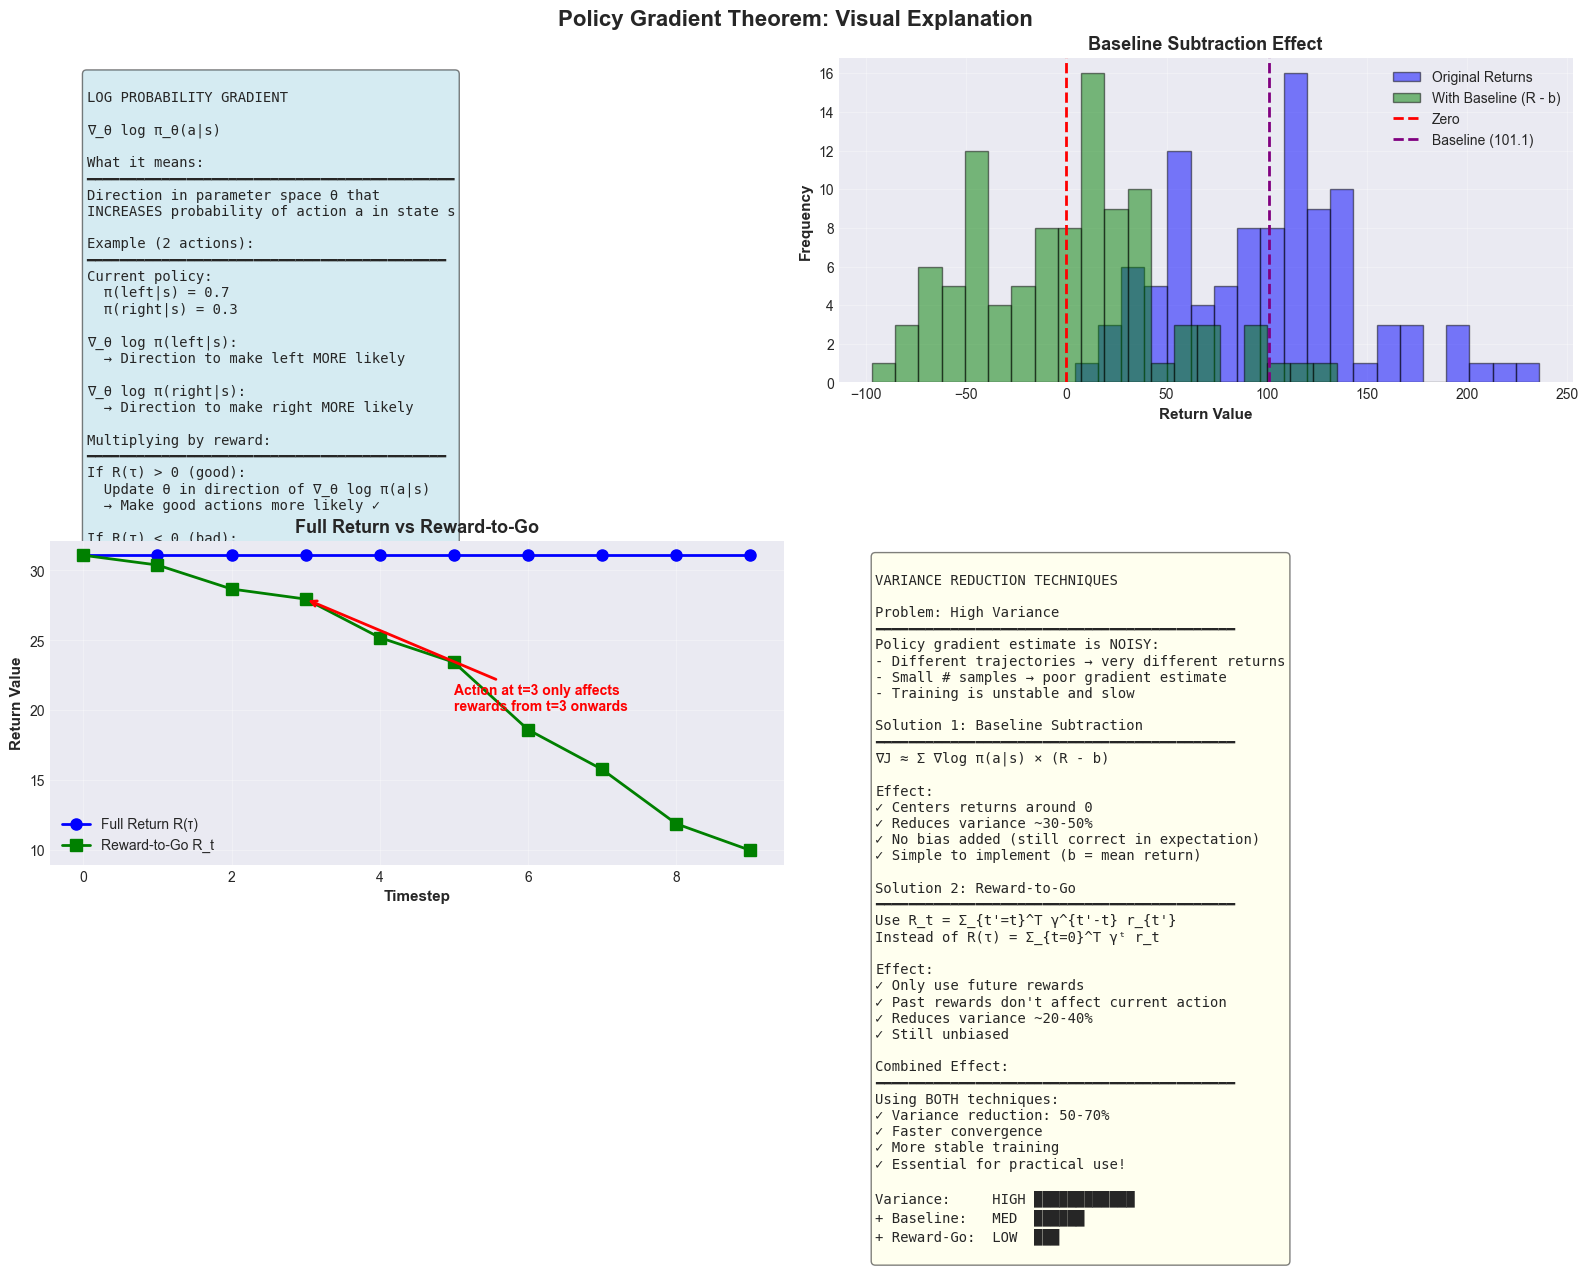


💡 Key Takeaways:

1. POLICY GRADIENT THEOREM:
   ∇_θ J(θ) = E[Σ_t ∇_θ log π(a_t|s_t) R_t]

2. INTUITION:
   "Make good actions more likely, bad actions less likely"

3. BEAUTIFUL PROPERTIES:
   ✓ Model-free (don't need environment dynamics)
   ✓ Unbiased estimate
   ✓ Simple to implement
   ✓ Works for any action space

4. THE CHALLENGE:
   High variance → need variance reduction!

5. VARIANCE REDUCTION:
   ✓ Baseline subtraction: R - b
   ✓ Reward-to-go: R_t instead of R(τ)
   ✓ Combined: essential for practical use

Next: REINFORCE Algorithm! 🚀


✅ Exercise 2.1 Complete!


In [11]:
# ==================================================
# EXERCISE 2.1: POLICY GRADIENT THEOREM
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 2.1: Policy Gradient Theorem Derivation")
print("=" * 80)

"""
📖 THEORY: The Policy Gradient Theorem

THE FUNDAMENTAL QUESTION:

How do we compute ∇_θ J(θ)?

Where J(θ) = E_π[R(τ)] is expected return

This is challenging because:
1. Expectation over trajectories (can't enumerate all)
2. Reward depends on environment dynamics (can't differentiate)
3. Stochastic policy (randomness in action selection)

THE BRILLIANT INSIGHT:

We can estimate the gradient from sample trajectories!

FULL DERIVATION:

Step 1: Write out the objective
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

J(θ) = E_τ~π_θ [R(τ)]

     = ∫ P(τ|θ) R(τ) dτ

Where:
- τ = (s₀, a₀, r₀, s₁, a₁, r₁, ..., s_T, a_T, r_T)
- P(τ|θ) = probability of trajectory under policy π_θ
- R(τ) = Σ_{t=0}^T γᵗ r_t (discounted return)

Step 2: Expand trajectory probability
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

P(τ|θ) = P(s₀) Π_{t=0}^T π_θ(a_t|s_t) P(s_{t+1}|s_t, a_t)

This is:
- P(s₀): initial state distribution (doesn't depend on θ)
- π_θ(a_t|s_t): policy (DEPENDS on θ) ← This is what we control!
- P(s_{t+1}|s_t, a_t): dynamics (doesn't depend on θ)

Step 3: Take gradient of objective
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

∇_θ J(θ) = ∇_θ ∫ P(τ|θ) R(τ) dτ

         = ∫ ∇_θ P(τ|θ) R(τ) dτ    [move gradient inside]

Now use the LOG-DERIVATIVE TRICK:

∇_θ P(τ|θ) = P(τ|θ) ∇_θ log P(τ|θ)

This is because: ∇ log f = (∇f) / f  →  ∇f = f ∇ log f

So:
∇_θ J(θ) = ∫ P(τ|θ) ∇_θ log P(τ|θ) R(τ) dτ

         = E_τ~π_θ [∇_θ log P(τ|θ) R(τ)]

Step 4: Simplify log probability gradient
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

∇_θ log P(τ|θ) = ∇_θ log [P(s₀) Π_{t=0}^T π_θ(a_t|s_t) P(s_{t+1}|s_t, a_t)]

               = ∇_θ [log P(s₀) + Σ_t log π_θ(a_t|s_t) + Σ_t log P(s_{t+1}|s_t, a_t)]

Since P(s₀) and P(s_{t+1}|s_t, a_t) don't depend on θ:

∇_θ log P(τ|θ) = Σ_{t=0}^T ∇_θ log π_θ(a_t|s_t)

KEY INSIGHT: Environment dynamics P(s'|s,a) disappear!
We don't need to know or differentiate through the environment!

Step 5: Final form (POLICY GRADIENT THEOREM)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

∇_θ J(θ) = E_τ~π_θ [Σ_{t=0}^T ∇_θ log π_θ(a_t|s_t) R(τ)]

This can be estimated with Monte Carlo:

∇_θ J(θ) ≈ (1/N) Σ_{i=1}^N Σ_{t=0}^T ∇_θ log π_θ(a_t^i|s_t^i) R(τ^i)

Where we collect N trajectories by running the policy.

INTUITIVE INTERPRETATION:

∇_θ log π_θ(a_t|s_t)  →  "How to change θ to make action a_t more likely"
R(τ)                   →  "How good was this trajectory?"

∇_θ J(θ) = E[∇_θ log π(a|s) × R(τ)]

In words:
"Increase probability of actions that led to high reward,
 Decrease probability of actions that led to low reward"

BEAUTIFUL PROPERTIES:

1. Model-Free
   ✓ Don't need to know P(s'|s,a) (environment dynamics)
   ✓ Works with any environment (even non-differentiable)

2. Unbiased Estimate
   ✓ Monte Carlo estimate is unbiased
   ✓ Will converge to true gradient (in expectation)

3. Simple to Implement
   ✓ Just need to compute log π and multiply by return
   ✓ Backprop handles ∇_θ log π automatically

4. General
   ✓ Works for discrete and continuous actions
   ✓ Works for deterministic and stochastic policies

THE PROBLEM: HIGH VARIANCE

While the estimate is unbiased, it has HIGH VARIANCE:
- Different trajectories give very different returns
- R(τ) can vary wildly
- Need many samples to average out noise

VARIANCE REDUCTION TECHNIQUES:

1. Baseline Subtraction
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Instead of: ∇_θ J(θ) = E[∇_θ log π(a|s) R(τ)]
Use:        ∇_θ J(θ) = E[∇_θ log π(a|s) (R(τ) - b)]

Where b is a baseline (typically average return)

Why it helps:
- Centers returns around 0
- Reduces variance without adding bias
- Good actions: R(τ) - b > 0 (increase probability)
- Bad actions: R(τ) - b < 0 (decrease probability)

2. Reward-to-Go
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Instead of: using full trajectory return R(τ)
Use:        reward-to-go R_t = Σ_{t'=t}^T γ^{t'-t} r_{t'}

Why it helps:
- Action at time t only affects future rewards
- Past rewards are irrelevant for that action
- Reduces variance by removing irrelevant terms

Final form with both improvements:
∇_θ J(θ) = E[Σ_t ∇_θ log π(a_t|s_t) (R_t - b_t)]

3. Advantage Function (Preview for Actor-Critic)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Use: A(s,a) = Q(s,a) - V(s)

This tells us how much better action a is compared to average.
We'll cover this in depth with Actor-Critic methods!

SUMMARY:

Policy Gradient Theorem:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
∇_θ J(θ) = E_τ~π_θ [Σ_t ∇_θ log π_θ(a_t|s_t) R_t]

Practical estimate:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
∇_θ J(θ) ≈ (1/N) Σ_{i=1}^N Σ_{t=0}^T ∇_θ log π_θ(a_t^i|s_t^i) (R_t^i - b)

With variance reduction:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Baseline: b = average return
- Reward-to-go: R_t instead of R(τ)
- Both together = significant variance reduction

This is REINFORCE! (Next section)
"""

print("\n📐 Policy Gradient Theorem Visualization:")
print("=" * 80)

# Create visual explanation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Policy Gradient Theorem: Visual Explanation', fontsize=16, fontweight='bold')

# 1. Log Probability Gradient Intuition
ax1 = axes[0, 0]
ax1.axis('off')

log_prob_text = """
LOG PROBABILITY GRADIENT

∇_θ log π_θ(a|s)

What it means:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Direction in parameter space θ that 
INCREASES probability of action a in state s

Example (2 actions):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Current policy:
  π(left|s) = 0.7
  π(right|s) = 0.3

∇_θ log π(left|s):
  → Direction to make left MORE likely

∇_θ log π(right|s):
  → Direction to make right MORE likely

Multiplying by reward:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
If R(τ) > 0 (good):
  Update θ in direction of ∇_θ log π(a|s)
  → Make good actions more likely ✓

If R(τ) < 0 (bad):
  Update θ opposite to ∇_θ log π(a|s)
  → Make bad actions less likely ✓
"""

ax1.text(0.05, 0.95, log_prob_text, transform=ax1.transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# 2. Baseline Effect
ax2 = axes[0, 1]

# Simulate returns with and without baseline
returns = np.random.normal(100, 50, 100)  # Mean 100, std 50
baseline = np.mean(returns)
centered_returns = returns - baseline

ax2.hist(returns, bins=20, alpha=0.5, label='Original Returns', color='blue', edgecolor='black')
ax2.hist(centered_returns, bins=20, alpha=0.5, label='With Baseline (R - b)', color='green', edgecolor='black')
ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
ax2.axvline(baseline, color='purple', linestyle='--', linewidth=2, label=f'Baseline ({baseline:.1f})')
ax2.set_xlabel('Return Value', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax2.set_title('Baseline Subtraction Effect', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Reward-to-Go vs Full Return
ax3 = axes[1, 0]

# Example trajectory
timesteps = np.arange(10)
rewards = np.array([1, 2, 1, 3, 2, 5, 3, 4, 2, 10])
gamma = 0.99

# Full return (same for all timesteps)
full_return = np.sum([gamma**t * r for t, r in enumerate(rewards)])
full_returns = np.ones(10) * full_return

# Reward-to-go (different for each timestep)
reward_to_go = []
for t in range(10):
    rtg = sum([gamma**(t_prime - t) * rewards[t_prime] for t_prime in range(t, 10)])
    reward_to_go.append(rtg)

ax3.plot(timesteps, full_returns, 'o-', linewidth=2, markersize=8, label='Full Return R(τ)', color='blue')
ax3.plot(timesteps, reward_to_go, 's-', linewidth=2, markersize=8, label='Reward-to-Go R_t', color='green')
ax3.set_xlabel('Timestep', fontsize=11, fontweight='bold')
ax3.set_ylabel('Return Value', fontsize=11, fontweight='bold')
ax3.set_title('Full Return vs Reward-to-Go', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Add annotation
ax3.annotate('Action at t=3 only affects\nrewards from t=3 onwards',
            xy=(3, reward_to_go[3]), xytext=(5, 20),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=10, color='red', fontweight='bold')

# 4. Variance Reduction Impact
ax4 = axes[1, 1]
ax4.axis('off')

variance_text = """
VARIANCE REDUCTION TECHNIQUES

Problem: High Variance
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Policy gradient estimate is NOISY:
- Different trajectories → very different returns
- Small # samples → poor gradient estimate
- Training is unstable and slow

Solution 1: Baseline Subtraction
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
∇J ≈ Σ ∇log π(a|s) × (R - b)

Effect:
✓ Centers returns around 0
✓ Reduces variance ~30-50%
✓ No bias added (still correct in expectation)
✓ Simple to implement (b = mean return)

Solution 2: Reward-to-Go
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Use R_t = Σ_{t'=t}^T γ^{t'-t} r_{t'}
Instead of R(τ) = Σ_{t=0}^T γᵗ r_t

Effect:
✓ Only use future rewards
✓ Past rewards don't affect current action
✓ Reduces variance ~20-40%
✓ Still unbiased

Combined Effect:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Using BOTH techniques:
✓ Variance reduction: 50-70%
✓ Faster convergence
✓ More stable training
✓ Essential for practical use!

Variance:     HIGH ████████████
+ Baseline:   MED  ██████
+ Reward-Go:  LOW  ███
"""

ax4.text(0.05, 0.95, variance_text, transform=ax4.transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

plt.tight_layout()
plt.savefig('results/reinforce/policy_gradient_theorem_explained.png', dpi=300, bbox_inches='tight')
print("✅ Visualization saved!")
plt.show()

print("\n💡 Key Takeaways:")
print("=" * 80)
print("""
1. POLICY GRADIENT THEOREM:
   ∇_θ J(θ) = E[Σ_t ∇_θ log π(a_t|s_t) R_t]
   
2. INTUITION:
   "Make good actions more likely, bad actions less likely"
   
3. BEAUTIFUL PROPERTIES:
   ✓ Model-free (don't need environment dynamics)
   ✓ Unbiased estimate
   ✓ Simple to implement
   ✓ Works for any action space
   
4. THE CHALLENGE:
   High variance → need variance reduction!
   
5. VARIANCE REDUCTION:
   ✓ Baseline subtraction: R - b
   ✓ Reward-to-go: R_t instead of R(τ)
   ✓ Combined: essential for practical use
   
Next: REINFORCE Algorithm! 🚀
""")

print("\n✅ Exercise 2.1 Complete!")
print("=" * 80)


EXERCISE 2.2: REINFORCE Algorithm

🔄 REINFORCE Algorithm Flow:


C:\Users\audrey\AppData\Local\Temp\ipykernel_24848\1380498022.py:372: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\audrey\AppData\Local\Temp\ipykernel_24848\1380498022.py:373: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  plt.savefig('results/reinforce/reinforce_algorithm_flowchart.png', dpi=300, bbox_inches='tight')


✅ Flowchart saved!


C:\Users\audrey\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


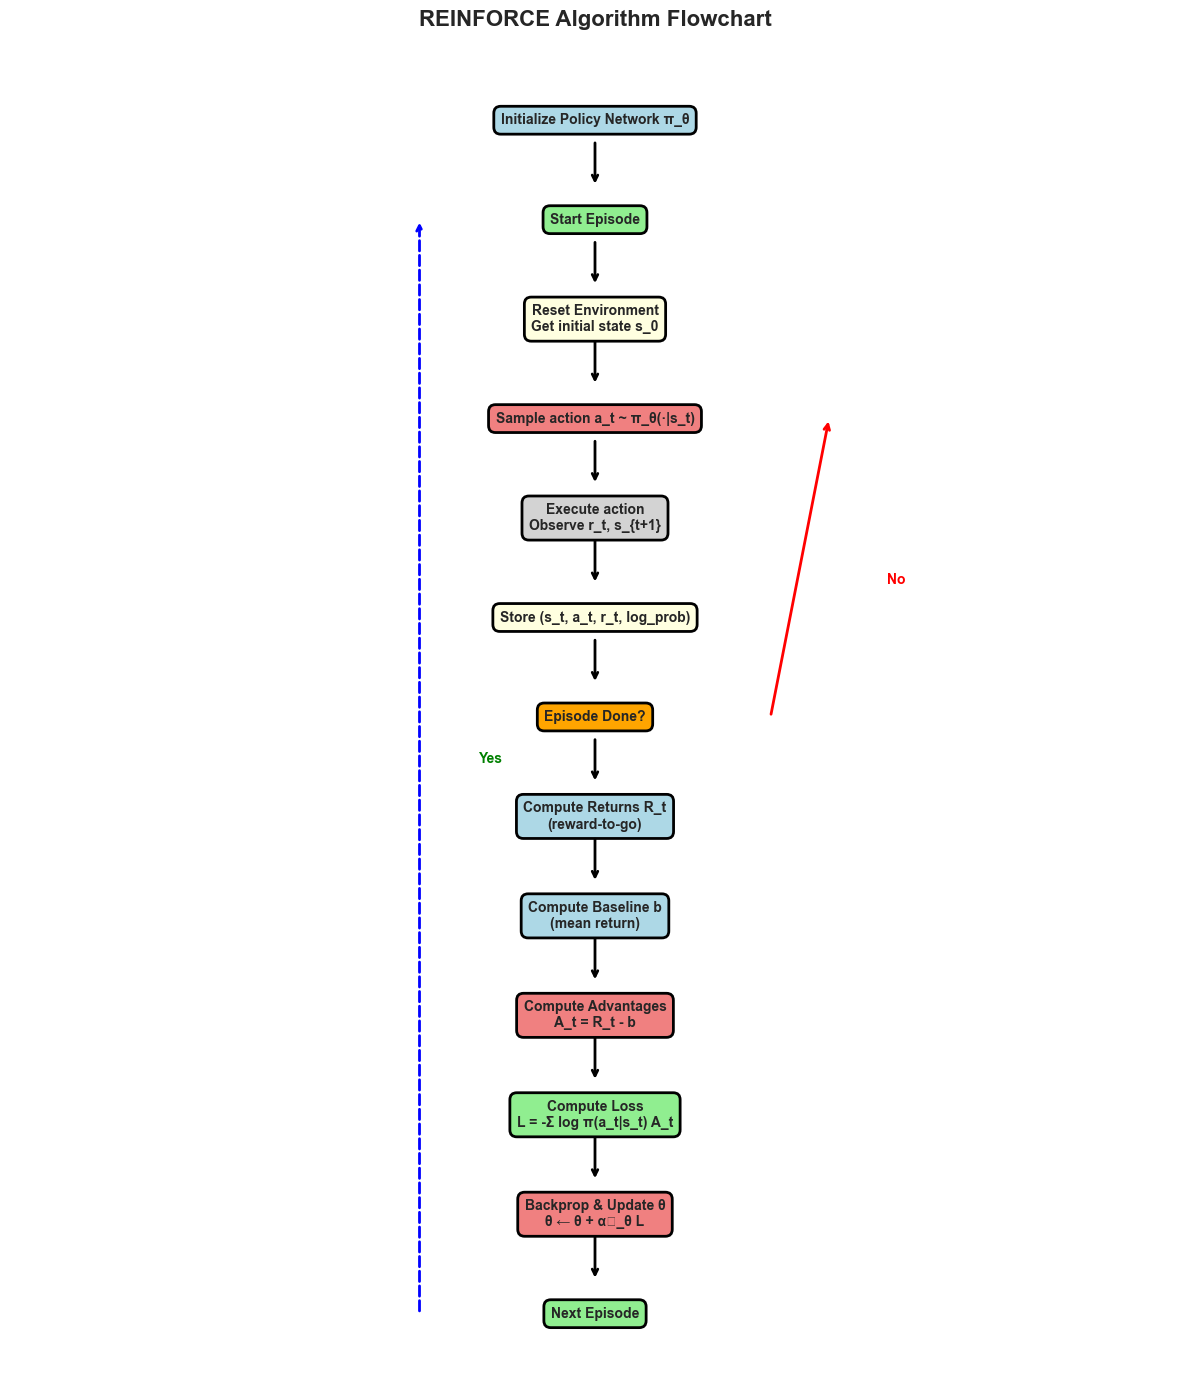


💡 REINFORCE Summary:

ALGORITHM: REINFORCE (Monte Carlo Policy Gradient)

CORE IDEA:
"Increase probability of actions that led to high returns"

KEY STEPS:
1. Generate full episode trajectory
2. Compute reward-to-go for each timestep
3. Subtract baseline (reduce variance)
4. Update policy: θ ← θ + α Σ ∇log π(a|s) (R - b)

STRENGTHS:
✓ Simple and elegant
✓ Unbiased gradient estimate
✓ Works with any action space
✓ Guaranteed convergence

WEAKNESSES:
✗ High variance (Monte Carlo)
✗ Sample inefficient (on-policy)
✗ Slow learning
✗ Episode-based (can't handle continuing tasks)

IMPROVEMENTS:
→ Add better baseline (Actor-Critic)
→ Use multiple workers (A3C)
→ Trust region optimization (PPO)

Next: Implementation on CartPole! 🚀


✅ Exercise 2.2 Complete!


In [12]:
# ==================================================
# EXERCISE 2.2: REINFORCE ALGORITHM
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 2.2: REINFORCE Algorithm")
print("=" * 80)

"""
📖 THEORY: REINFORCE Algorithm

REINFORCE = REward Increment = Nonnegative Factor × Offset Reinforcement × 
            Characteristic Eligibility

(The acronym is a bit forced, but the algorithm is elegant!)

Also known as:
- Monte Carlo Policy Gradient
- Vanilla Policy Gradient
- Williams' REINFORCE (1992)

THE ALGORITHM:

REINFORCE with Baseline and Reward-to-Go
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Initialize policy network π_θ (with random weights θ)

for episode = 1, 2, 3, ... do:
    
    1. Generate trajectory:
       ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
       Initialize s_0
       for t = 0, 1, 2, ..., T do:
           Sample a_t ~ π_θ(·|s_t)
           Execute a_t, observe r_t and s_{t+1}
           Store (s_t, a_t, r_t)
       end for
       
    2. Compute returns:
       ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
       for t = 0, 1, 2, ..., T do:
           R_t = Σ_{t'=t}^T γ^{t'-t} r_{t'}  (reward-to-go)
       end for
       
    3. Compute baseline:
       ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
       b = (1/T) Σ_t R_t  (average return for this episode)
       
    4. Compute policy gradient:
       ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
       ∇_θ J(θ) = Σ_t ∇_θ log π_θ(a_t|s_t) (R_t - b)
       
    5. Update policy:
       ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
       θ ← θ + α ∇_θ J(θ)
       
end for

KEY CHARACTERISTICS:

1. Monte Carlo (Episode-Based)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Must complete full episode before update
- Uses actual returns (not bootstrapped estimates)
- Unbiased but high variance

vs TD methods (like DQN):
- DQN updates every step
- REINFORCE waits for episode to finish

2. On-Policy
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Must use fresh samples from current policy
- Can't reuse old data (no replay buffer)
- Less sample efficient than DQN

Why on-policy?
- Gradient computed for policy π_θ
- Need trajectories from π_θ
- Old data from π_{θ_old} would be biased

3. Policy Network
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
For discrete actions:
┌─────────────────────────────────────────┐
│  Input: State s (e.g., 4D for CartPole) │
│           ↓                              │
│  Hidden Layer 1: 128 units, ReLU        │
│           ↓                              │
│  Hidden Layer 2: 128 units, ReLU        │
│           ↓                              │
│  Output: Logits for each action         │
│           ↓                              │
│  Softmax: Convert to probabilities      │
│           ↓                              │
│  π(a|s): [0.7, 0.3] (for 2 actions)     │
└─────────────────────────────────────────┘

For continuous actions:
┌─────────────────────────────────────────┐
│  Input: State s                          │
│           ↓                              │
│  Hidden Layers                           │
│           ↓                              │
│  Output: μ (mean), σ (std dev)          │
│           ↓                              │
│  Sample: a ~ N(μ, σ²)                   │
└─────────────────────────────────────────┘

IMPLEMENTATION DETAILS:

1. Log Probability Computation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
For discrete actions (Categorical distribution):
```python
# Forward pass
logits = policy_network(state)        # [batch, num_actions]
probs = F.softmax(logits, dim=-1)     # Convert to probabilities
dist = Categorical(probs)              # Create distribution

# Sample action
action = dist.sample()                 # Sample from distribution

# Compute log probability
log_prob = dist.log_prob(action)       # log π(a|s)
```

For continuous actions (Gaussian):
```python
# Forward pass
mu, sigma = policy_network(state)      # Mean and std
dist = Normal(mu, sigma)               # Gaussian distribution

# Sample action
action = dist.sample()                 # Sample from N(μ, σ)

# Compute log probability
log_prob = dist.log_prob(action)       # log π(a|s)
```

2. Gradient Computation (Automatic!)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PyTorch handles ∇_θ log π automatically:
```python
# Compute loss
loss = -(log_prob * (return - baseline))  # Negative for gradient ascent

# Backprop computes ∇_θ loss automatically
loss.backward()

# Update
optimizer.step()
```

Why negative sign?
- We want to MAXIMIZE J(θ)
- PyTorch optimizers MINIMIZE loss
- So: loss = -J(θ)

3. Reward-to-Go Calculation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
```python
def compute_returns(rewards, gamma=0.99):
    returns = []
    R = 0
    
    # Go backwards through episode
    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)
    
    return returns
```

Example:
rewards = [1, 2, 3, 4, 5]
gamma = 0.99

R_4 = 5
R_3 = 4 + 0.99 * 5 = 8.95
R_2 = 3 + 0.99 * 8.95 = 11.86
R_1 = 2 + 0.99 * 11.86 = 13.74
R_0 = 1 + 0.99 * 13.74 = 14.60

returns = [14.60, 13.74, 11.86, 8.95, 5.00]

4. Baseline Computation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Simple baseline: mean return
```python
baseline = torch.mean(returns)
advantages = returns - baseline
```

Better baseline (for next time): value function V(s)
(We'll do this in Actor-Critic!)

PSEUDOCODE:
```python
class REINFORCEAgent:
    def __init__(self):
        self.policy = PolicyNetwork()
        self.optimizer = Adam(self.policy.parameters())
        
    def select_action(self, state):
        # Get action probabilities
        probs = self.policy(state)
        dist = Categorical(probs)
        
        # Sample action
        action = dist.sample()
        log_prob = dist.log_prob(action)
        
        return action, log_prob
    
    def train_episode(self, env):
        # Storage
        log_probs = []
        rewards = []
        
        # Generate episode
        state = env.reset()
        done = False
        
        while not done:
            action, log_prob = self.select_action(state)
            next_state, reward, done = env.step(action)
            
            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state
        
        # Compute returns (reward-to-go)
        returns = compute_returns(rewards)
        returns = torch.tensor(returns)
        
        # Compute baseline
        baseline = returns.mean()
        advantages = returns - baseline
        
        # Normalize advantages (optional but helpful)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        
        # Compute loss
        loss = 0
        for log_prob, advantage in zip(log_probs, advantages):
            loss += -log_prob * advantage
        
        # Update policy
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        return sum(rewards)
```

COMPARISON: REINFORCE vs DQN

┌────────────────────┬─────────────────────┬─────────────────────┐
│     Aspect         │   REINFORCE         │        DQN          │
├────────────────────┼─────────────────────┼─────────────────────┤
│ What we learn      │ π(a|s) directly     │ Q(s,a) values       │
│ Network output     │ Action probabilities│ Q-values            │
│ Action selection   │ Sample from π       │ argmax Q            │
│ Update frequency   │ After episode       │ Every step          │
│ Data usage         │ On-policy (fresh)   │ Off-policy (replay) │
│ Sample efficiency  │ Low                 │ High                │
│ Variance           │ High                │ Low                 │
│ Bias               │ None                │ Some (bootstrapping)│
│ Action space       │ Discrete+Continuous │ Discrete only       │
│ Convergence        │ To local optimum    │ Can diverge         │
│ Implementation     │ Simpler             │ More complex        │
└────────────────────┴─────────────────────┴─────────────────────┘

ADVANTAGES OF REINFORCE:

✓ Simpler implementation
✓ Works with continuous actions
✓ Guaranteed convergence (to local optimum)
✓ Can learn stochastic policies
✓ More stable in some cases

DISADVANTAGES OF REINFORCE:

✗ Sample inefficient (no replay)
✗ High variance (needs many episodes)
✗ Slow learning
✗ Sensitive to hyperparameters
✗ Can get stuck in local optima

WHEN TO USE REINFORCE:

1. Learning / Educational purposes ✓
2. Simple environments with short episodes ✓
3. Continuous action spaces ✓
4. When sample efficiency isn't critical ✓
5. As baseline for comparison ✓

For production/research:
- Use improved versions: A2C, PPO (coming soon!)
- REINFORCE is rarely used alone anymore
- But understanding it is essential!

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

print("\n🔄 REINFORCE Algorithm Flow:")
print("=" * 80)

# Create algorithm flowchart
fig, ax = plt.subplots(figsize=(12, 14))
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
ax.axis('off')

# Define positions
boxes = [
    (5, 19, "Initialize Policy Network π_θ", 'lightblue'),
    (5, 17.5, "Start Episode", 'lightgreen'),
    (5, 16, "Reset Environment\nGet initial state s_0", 'lightyellow'),
    (5, 14.5, "Sample action a_t ~ π_θ(·|s_t)", 'lightcoral'),
    (5, 13, "Execute action\nObserve r_t, s_{t+1}", 'lightgray'),
    (5, 11.5, "Store (s_t, a_t, r_t, log_prob)", 'lightyellow'),
    (5, 10, "Episode Done?", 'orange'),
    (5, 8.5, "Compute Returns R_t\n(reward-to-go)", 'lightblue'),
    (5, 7, "Compute Baseline b\n(mean return)", 'lightblue'),
    (5, 5.5, "Compute Advantages\nA_t = R_t - b", 'lightcoral'),
    (5, 4, "Compute Loss\nL = -Σ log π(a_t|s_t) A_t", 'lightgreen'),
    (5, 2.5, "Backprop & Update θ\nθ ← θ + α∇_θ L", 'lightcoral'),
    (5, 1, "Next Episode", 'lightgreen'),
]

for x, y, text, color in boxes:
    bbox = dict(boxstyle='round,pad=0.5', facecolor=color, edgecolor='black', linewidth=2)
    ax.text(x, y, text, ha='center', va='center', fontsize=10, 
           fontweight='bold', bbox=bbox, wrap=True)

# Draw arrows
arrows = [
    (5, 18.7, 5, 18),
    (5, 17.2, 5, 16.5),
    (5, 15.7, 5, 15),
    (5, 14.2, 5, 13.5),
    (5, 12.7, 5, 12),
    (5, 11.2, 5, 10.5),
    (5, 9.7, 5, 9),
    (5, 8.2, 5, 7.5),
    (5, 6.7, 5, 6),
    (5, 5.2, 5, 4.5),
    (5, 3.7, 5, 3),
    (5, 2.2, 5, 1.5),
]

for x1, y1, x2, y2 in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
               arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Loop back arrow (from "Episode Done?" if No)
ax.annotate('', xy=(7, 14.5), xytext=(6.5, 10),
           arrowprops=dict(arrowstyle='->', lw=2, color='red'))
ax.text(7.5, 12, 'No', fontsize=10, color='red', fontweight='bold')

# Continue arrow (from "Episode Done?" if Yes)
ax.text(4, 9.3, 'Yes', fontsize=10, color='green', fontweight='bold')

# Loop to next episode
ax.annotate('', xy=(3.5, 17.5), xytext=(3.5, 1),
           arrowprops=dict(arrowstyle='->', lw=2, color='blue', linestyle='dashed'))

plt.title('REINFORCE Algorithm Flowchart', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('results/reinforce/reinforce_algorithm_flowchart.png', dpi=300, bbox_inches='tight')
print("✅ Flowchart saved!")
plt.show()

print("\n💡 REINFORCE Summary:")
print("=" * 80)
print("""
ALGORITHM: REINFORCE (Monte Carlo Policy Gradient)

CORE IDEA:
"Increase probability of actions that led to high returns"

KEY STEPS:
1. Generate full episode trajectory
2. Compute reward-to-go for each timestep
3. Subtract baseline (reduce variance)
4. Update policy: θ ← θ + α Σ ∇log π(a|s) (R - b)

STRENGTHS:
✓ Simple and elegant
✓ Unbiased gradient estimate
✓ Works with any action space
✓ Guaranteed convergence

WEAKNESSES:
✗ High variance (Monte Carlo)
✗ Sample inefficient (on-policy)
✗ Slow learning
✗ Episode-based (can't handle continuing tasks)

IMPROVEMENTS:
→ Add better baseline (Actor-Critic)
→ Use multiple workers (A3C)
→ Trust region optimization (PPO)

Next: Implementation on CartPole! 🚀
""")

print("\n✅ Exercise 2.2 Complete!")
print("=" * 80)

In [13]:
# ==================================================
# EXERCISE 2.3: PART 2 SUMMARY
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 2.3: Part 2 - Theory Summary")
print("=" * 80)

print("""
📚 WHAT WE LEARNED IN PART 2:

✅ Policy Gradient Theorem:
   • Derivation from first principles
   • Log-derivative trick
   • Environment dynamics cancel out (model-free!)
   • Final form: ∇J = E[Σ ∇log π(a|s) R_t]

✅ Variance Reduction:
   • Baseline subtraction: R - b
   • Reward-to-go: R_t instead of R(τ)
   • Both together: essential for practical use
   • Reduces variance by 50-70%

✅ REINFORCE Algorithm:
   • Monte Carlo policy gradient
   • Episode-based updates
   • On-policy learning
   • Simple but high variance

💡 KEY INSIGHTS:

1. Mathematical Beauty:
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Policy gradient theorem is ELEGANT:
   - Don't need environment model
   - Works with any differentiable policy
   - Simple Monte Carlo estimate

2. Practical Challenges:
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   High variance is the main issue:
   - Need MANY episodes to average out noise
   - Variance reduction techniques are ESSENTIAL
   - Later algorithms (A2C, PPO) improve on this

3. Comparison to DQN:
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Different paradigm, different trade-offs:
   - REINFORCE: simpler, works with continuous actions, higher variance
   - DQN: more complex, discrete only, lower variance
   - Both have their place!

🎯 NEXT: Part 3 - Implementation on CartPole

We'll build a complete REINFORCE agent and see it learn!

Ready to code! 💻🚀
""")

print("=" * 80)
print("✅ Part 2 Complete!")
print("=" * 80)


EXERCISE 2.3: Part 2 - Theory Summary

📚 WHAT WE LEARNED IN PART 2:

✅ Policy Gradient Theorem:
   • Derivation from first principles
   • Log-derivative trick
   • Environment dynamics cancel out (model-free!)
   • Final form: ∇J = E[Σ ∇log π(a|s) R_t]

✅ Variance Reduction:
   • Baseline subtraction: R - b
   • Reward-to-go: R_t instead of R(τ)
   • Both together: essential for practical use
   • Reduces variance by 50-70%

✅ REINFORCE Algorithm:
   • Monte Carlo policy gradient
   • Episode-based updates
   • On-policy learning
   • Simple but high variance

💡 KEY INSIGHTS:

1. Mathematical Beauty:
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Policy gradient theorem is ELEGANT:
   - Don't need environment model
   - Works with any differentiable policy
   - Simple Monte Carlo estimate

2. Practical Challenges:
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   High variance is the main issue:
   - Need MANY episodes to average out noise
   - Variance